In [ ]:
# @title
#PEDRO
import pandas as pd
import numpy as np

# 1. CARREGAMENTO E DEFINIÇÕES
caminho_arquivo = "diabetes.csv"
df = pd.read_csv(caminho_arquivo)
colunas_fisiologicas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. ANÁLISE DOS DADOS ORIGINAIS (SUJOS)
stats_original = df.describe()
contagem_zeros = (df[colunas_fisiologicas] == 0).sum()
dist_original = df['Outcome'].value_counts()

# 3. LIMPEZA DOS DADOS
# Substituindo zeros por NaN e removendo as linhas
df_processado = df.copy()
df_processado[colunas_fisiologicas] = df_processado[colunas_fisiologicas].replace(0, np.nan)
df_limpo = df_processado.dropna()

# 4. ANÁLISE DOS DADOS LIMPOS
stats_limpo = df_limpo.describe()
dist_limpo = df_limpo['Outcome'].value_counts()
medias_por_diagnostico = df_limpo.groupby('Outcome').mean()
skewness_limpo = df_limpo.drop('Outcome', axis=1).skew()


# RELATÓRIO DE ANÁLISE EXPLORATÓRIA: BANCO DE DADOS PIMA INDIANS DIABETES

**Tema:** Diagnóstico de Diabetes através de Aprendizado de Máquina

**Base utilizida:** Pima Indians Diabetes Database

**Fonte:** https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database/data

## Referência da base
>Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## Justificativa da escolha da base

* é uma base real, coletada pelo National Institute of Diabetes and Digestive and Kidney Diseases;
* permite a aplicação direta de modelos de classificação binária;
* possui variáveis clínicas fisiologicamente interpretáveis (glicose, IMC, insulina, etc.);
* permite discutir conceitos fundamentais de Machine Learning, como balanceamento de classes, tratamento de outliers e métricas de acurácia e sensibilidade.

## Limitações

* a base de dados é composta exclusivamente por mulheres de uma etnia específica, o que pode limitar a generalização para outras populações ou gêneros;
* fatores externos e de estilo de vida, como dieta detalhada e nível de atividade física diária, não estão descritos de
 forma qualitativa;
* algumas variáveis apresentam valores nulos preenchidos como **zero** (como pressão arterial e IMC), exigindo uma estratégia prévia de limpeza ou imputação de dados.

##Integrantes do grupo

* Pedro Medice Brum
* Lucas Pereira da Silva

#Repositório do GitHub


##Conveção do grupo

* <font color='blue'>Azul</font>: Pedro Medice Brum
* <font color='green'>Verde</font>: Lucas Pereira
* <font color='red'>Vermelho</font>: João Marcos Vicente
* <font color='purple'>Roxo</font>: Ian Araújo Figueirêdo
#<font color='blue'> 1. Definição do problema</font>

Na engenharia e na saúde, o monitoramento de variáveis fisiológicas e o uso de modelos preditivos são fundamentais para:

* rastreamento de condições crônicas;
* identificação de padrões de risco;
* auxílio ao diagnóstico precoce;
* avaliação de correlações entre indicadores biométricos;
* formulação de problemas de classificação e detecção de anomalias.

Nesta base, temos medições reais de 768 mulheres da etnia Pima, coletadas pelo National Institute of Diabetes and Digestive and Kidney Diseases. As variáveis incluem níveis de glicose, pressão arterial, índice de massa corporal (IMC), insulina, histórico familiar e número de gestações.

A pergunta principal deste estudo é:

> **Quais combinações de variáveis fisiológicas e padrões estatísticos melhor explicam e permitem prever a presença de diabetes em pacientes?**

Objetivos específicos:

* descrever a base e avaliar sua consistência estatística;
* tratar valores ausentes de forma tecnicamente justificável;
* investigar distribuições, correlações e a importância relativa de cada variável;
* discutir métricas de desempenho (acurácia, precisão e recall) em problemas de saúde;
* propor e implementar um modelo de aprendizado de máquina capaz de classificar novos diagnósticos com base nos dados fornecidos.

## <font color="blue">2. Leitura e organização da base em Python</font>

O processamento inicial consiste em:

* leitura do arquivo de dados em formato `.csv`;
* interpretação de valores nulos e inconsistentes;
* remoção de linhas contendo valores iguais a zero em colunas críticas (Glicose, Pressão Arterial, IMC, Insulina e Espessura da Pele), visto que representam ausência de coleta de dados e não valores fisiológicos reais;
* ajuste dos tipos de dados para garantir a compatibilidade com os algoritmos de aprendizado de máquina.




| | variavel | unidade | descricao |
|:---:|:---|:---:|:---|
| **0** | Pregnancies | - | Número de vezes que a paciente engravidou |
| **1** | Glucose | mg/dL | Concentração de glicose plasmática (teste de tolerância) |
| **2** | BloodPressure | mmHg | Pressão arterial diastólica |
| **3** | SkinThickness | mm | Espessura da dobra cutânea do tríceps |
| **4** | Insulin | mu U/ml | Nível de insulina sérica (2 horas após o teste) |
| **5** | BMI | kg/m² | Índice de Massa Corporal (Peso / Altura²) |
| **6** | DiabetesPedigree | - | Score de histórico familiar e propensão genética |
| **7** | Age | anos | Idade da paciente |
| **8** | Outcome | binário | Variável alvo (0 para não diabético, 1 para diabético) |



####ESTATÍSTICA DESCRITIVA: DADOS ORIGINAIS

| | Pregnancies | Glucose | BloodPressure | SkinThickness | Insulin | BMI | DiabetesPedigreeFunction | Age | Outcome |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **count** | 768.00 | 768.00 | 768.00 | 768.00 | 768.00 | 768.00 | 768.00 | 768.00 | 768.00 |
| **mean** | 3.85 | 120.89 | 69.11 | 20.54 | 79.80 | 31.99 | 0.47 | 33.24 | 0.35 |
| **std** | 3.37 | 31.97 | 19.36 | 15.95 | 115.24 | 7.88 | 0.33 | 11.76 | 0.48 |
| **min** | **0.00** | **0.00** | **0.00** | **0.00** | **0.00** | **0.00** | 0.08 | 21.00 | 0.00 |
| **25%** | 1.00 | 99.00 | 62.00 | 0.00 | 0.00 | 27.30 | 0.24 | 24.00 | 0.00 |
| **50%** | 3.00 | 117.00 | 72.00 | 23.00 | 30.50 | 32.00 | 0.37 | 29.00 | 0.00 |
| **75%** | 6.00 | 140.25 | 80.00 | 32.00 | 127.25 | 36.60 | 0.63 | 41.00 | 1.00 |
| **max** | 17.00 | 199.00 | 122.00 | 99.00 | 846.00 | 67.10 | 2.42 | 81.00 | 1.00 |


####  CONTAGEM DE ZEROS (DADOS FALSOS)

Ao analisar as variáveis onde o valor zero é clinicamente impossível, identificamos a seguinte quantidade de registros inconsistentes:

* **Glucose:** 5 valores nulos (0);
* **BloodPressure:** 35 valores nulos (0);
* **SkinThickness:** 227 valores nulos (0);
* **Insulin:** 374 valores nulos (0);
* **BMI:** 11 valores nulos (0).

> **Impacto:** A variável **Insulin** é a mais afetada, com quase 50% dos dados originais (374 de 768) sendo nulos. Isso reforça a importância da decisão de limpar a base para evitar que o modelo sofra um viés por dados faltantes.

##<font color="blue"> 3. Tratamento e preparação dos dados</font>

A análise inicial revelou valores "0" em variáveis como Glicose, Pressão e IMC, o que é clinicamente impossível e indica perda de dados (*missing data*).

Para garantir a confiabilidade do treinamento, optou-se pela **remoção das linhas** com inconsistências:

* **Conversão:** Os zeros foram substituídos por valores nulos (*NaN*).
* **Filtragem:** Linhas com dados faltantes foram descartadas para evitar ruídos no modelo.
* **Estratégia:** Priorizou-se o uso de dados 100% reais e completos, em vez de preencher lacunas com médias artificiais (imputação), assegurando um diagnóstico mais fiel à realidade clínica.

### ESTATÍSTICA DESCRITIVA: DADOS LIMPOS

| | Pregnancies | Glucose | BloodPressure | SkinThickness | Insulin | BMI | DiabetesPedigreeFunction | Age | Outcome |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **count** | 392.00 | 392.00 | 392.00 | 392.00 | 392.00 | 392.00 | 392.00 | 392.00 | 392.00 |
| **mean** | 3.30 | 122.63 | 70.66 | 29.15 | 156.06 | 33.09 | 0.52 | 30.86 | 0.33 |
| **std** | 3.21 | 30.86 | 12.50 | 10.52 | 118.84 | 7.03 | 0.35 | 10.20 | 0.47 |
| **min** | 0.00 | **56.00** | **24.00** | **7.00** | **14.00** | **18.20** | 0.09 | 21.00 | 0.00 |
| **25%** | 1.00 | 99.00 | 62.00 | 21.00 | 76.75 | 28.40 | 0.27 | 23.00 | 0.00 |
| **50%** | 2.00 | 119.00 | 70.00 | 29.00 | 125.50 | 33.20 | 0.45 | 27.00 | 0.00 |
| **75%** | 5.00 | 143.00 | 78.00 | 37.00 | 190.00 | 37.10 | 0.69 | 36.00 | 1.00 |
| **max** | 17.00 | 198.00 | 110.00 | 63.00 | 846.00 | 67.10 | 2.42 | 81.00 | 1.00 |


###  RELATÓRIO DE LIMPEZA

Após o processamento e a filtragem das inconsistências, o conjunto de dados apresentou o seguinte balanço:

* **Linhas originais:** 768
* **Linhas removidas:** 376 (contendo valores nulos/zeros inconsistentes)
* **Linhas mantidas (limpas):** 392

---
> **Análise:** A remoção de aproximadamente **49%** da base original foi necessária para garantir que o modelo de Machine Learning não fosse treinado com dados ruidosos ou incompletos. Priorizamos a integridade dos dados para obter resultados de classificação confiáveis.

* Fim dos Zeros: Destaque que os valores mínimos agora são coerentes. Por exemplo, o IMC mínimo é 18.20 e a Glicose é 56.00, valores possíveis em um ser humano vivo.

* Correção da Insulina (Diabetes Tipo 2): Como o estudo foca em Diabetes Tipo 2 — caracterizado por resistência à insulina e não pela ausência total do hormônio — a remoção dos valores "0" foi indispensável para eliminar dados clinicamente impossíveis e corrigir o viés estatístico da base.

* Mudança na Média de Insulina: Repare que a média da Insulina saltou de 79.80 (nos dados sujos) para 156.06. Isso prova que os zeros estavam "puxando" a estatística para baixo de forma errônea.


### DISTRIBUIÇÃO DO DIAGNÓSTICO (APÓS TRATAMENTO)

Após a filtragem dos dados inconsistentes, a distribuição das classes na variável alvo (**Outcome**) ficou configurada da seguinte forma:

* **Saudável (0):** 262 registros
* **Diabetes (1):** 130 registros



##<font color="blue"> 4. Avaliação de distribuições e teste de normalidade</font>

Para fortalecer a etapa de modelagem, é necessário verificar formalmente qual modelo matemático melhor descreve o comportamento biológico das variáveis. Vários algoritmos clássicos de aprendizado de máquina assumem distribuições gaussianas (Normais), e validar essa premissa previne perdas drásticas de precisão.


###<font color="blue"> 4.1 Interpretação da Estatística Descritiva: Assimetria (Skewness) e Curtose</font>

Para diagnosticar o comportamento do sistema biológico antes da modelagem matemática, utilizamos duas métricas que medem a "geometria" da distribuição dos dados em relação a uma curva Normal teórica:
* **Assimetria (Skewness):** Mede o deslocamento lateral da massa de dados. Valores distantes de zero indicam "caudas longas", significando que o sistema opera majoritariamente em um nível, mas sofre desvios direcionais.
* **Curtose (Excesso):** Mede o "achatamento" da curva e o peso de suas caudas. Na engenharia de dados, ela quantifica a propensão do sistema a gerar *outliers* (valores extremos).

Ao cruzar essas duas métricas, é possível classificar todas as variáveis da base em quatro padrões operacionais distintos:

1. **Regime de Estabilidade (Simetria Gaussiana):** Em sistemas fisiológicos, algumas grandezas operam sob forte regulação natural, oscilando de forma homogênea em torno de uma média (assimetria e curtose próximas a zero). Elas não geram grandes sobressaltos ou anomalias.
* *Exemplos na base:* **BloodPressure** (Pressão Arterial) e **SkinThickness** (Espessura da Dobra Cutânea).

2. **Transientes Extremos (Caudas Pesadas):** Ocorrem quando o sistema opera em um "regime basal" muito restrito a maior parte do tempo (formando um pico agudo e alta curtose), mas é suscetível a anomalias de altíssima amplitude (alta assimetria). Para a Inteligência Artificial, esses transientes não são ruídos de medição, mas o exato gatilho de falha metabólica.
* *Exemplos na base:* **Insulin** (picos de resistência insulínica) e **DiabetesPedigreeFunction** (peso genético excepcional).

3. **Achatamento por Sobreposição (Curtose Negativa):** Quando uma distribuição apresenta curtose negativa (platicúrtica), sua curva é mais achatada. Isso geralmente indica a presença de um comportamento bimodal, onde a grandeza não se concentra em um único pico, mas esconde dois perfis operacionais misturados na mesma amostra (os níveis do grupo saudável vs. os do grupo patológico).
* *Exemplo na base:* **Glucose** (Glicose).

4. **Decaimento Demográfico (Expansão Moderada):** Grandezas ligadas ao histórico de vida ou estrutura física tendem a seguir um desvio padrão natural de amostragem humana. Elas apresentam curtose e assimetria moderadamente positivas, refletindo uma concentração natural no início da curva que se estica suavemente para a direita devido a casos biologicamente esperados, mas menos frequentes.
* *Exemplos na base:* **Age** (Idade), **BMI** (Índice de Massa Corporal) e **Pregnancies** (Número de Gestações).

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


# ---------------------------------------------------------
# 1. MÉTRICAS AVANÇADAS VIA PANDAS
# ---------------------------------------------------------
resumo_estatistico = df_limpo.drop('Outcome', axis=1).agg(['mean', 'median', 'skew', 'kurt']).T
resumo_estatistico.columns = ['Média', 'Mediana', 'Assimetria (Skew)', 'Curtose (Excesso)']

display(resumo_estatistico)

,Média,Mediana,Assimetria (Skew),Curtose (Excesso)
Pregnancies,3.301020,2.0000,1.335596,1.486342
Glucose,122.627551,119.0000,0.517850,-0.483227
BloodPressure,70.663265,70.0000,-0.087516,0.795404
SkinThickness,29.145408,29.0000,0.209311,-0.457696
Insulin,156.056122,125.5000,2.165116,6.356505
BMI,33.086224,33.2000,0.663485,1.556513
DiabetesPedigreeFunction,0.523046,0.4495,1.959101,6.366690
Age,30.864796,27.0000,1.403607,1.737531


###<font color="blue"> 4.2 Teste de Aderência Matemática

Para dar total transparência à análise paramétrica, desenvolvemos uma rotina que submete todas as grandezas preditoras a testes de aderência competitivos com as distribuições **Normal, Lognormal, Gamma e Weibull**.

A tabela abaixo exibe a "memória de cálculo" com o desempenho de cada modelo para cada variável, ranqueados pela minimização do **Critério de Informação de Akaike (AIC)** (quanto menor, melhor o ajuste), acompanhados da estatística de **Kolmogorov-Smirnov (KS)**.

In [ ]:
# @title
# ---------------------------------------------------------
# 2. TESTE DE ADERÊNCIA MATEMÁTICA (Todas as Distribuições)
# ---------------------------------------------------------
colunas_para_testar = df_limpo.columns.drop('Outcome')

distribuicoes = {
    'normal': stats.norm,
    'lognormal': stats.lognorm,
    'gamma': stats.gamma,
    'weibull_min': stats.weibull_min
}

resultados_completos = []

for col in colunas_para_testar:
    dados = df_limpo[col].dropna()

    # Tratamento de segurança para distribuições que não aceitam zero exato
    if dados.min() <= 0:
        dados_fit = dados + 0.0001
    else:
        dados_fit = dados

    # Loop que testa CADA modelo e salva TODOS os resultados
    for nome, dist in distribuicoes.items():
        try:
            params = dist.fit(dados_fit)
            ks_stat, ks_pvalor = stats.kstest(dados_fit, dist.cdf, args=params)

            # Cálculo do AIC
            loglik = np.sum(dist.logpdf(dados_fit, *params))
            k = len(params)
            aic = 2 * k - 2 * loglik

            resultados_completos.append({
                'variavel': col,
                'distribuicao': nome,
                'AIC': round(aic, 4),
                'KS_stat': round(ks_stat, 4),
                'KS_pvalor': round(ks_pvalor, 4)
            })
        except:
            continue # Se divergir, ignora

# Cria o DataFrame e ordena por Variável e depois pelo AIC
tabela_aderencia = pd.DataFrame(resultados_completos)
tabela_aderencia = tabela_aderencia.sort_values(by=['variavel', 'AIC']).reset_index(drop=True)

display(tabela_aderencia)

,variavel,distribuicao,AIC,KS_stat,KS_pvalor
0,Age,gamma,1772.7724,0.1855,0.0000
1,Age,lognormal,2064.4007,0.4595,0.0000
2,Age,weibull_min,2088.8106,0.0842,0.0073
3,Age,normal,2936.2582,0.1822,0.0000
4,BMI,lognormal,2625.0344,0.0494,0.2851
5,BMI,gamma,2625.3264,0.0493,0.2871
6,BMI,weibull_min,2628.5281,0.0459,0.3703
7,BMI,normal,2644.1318,0.0389,0.5787
8,BloodPressure,normal,3095.3726,0.0451,0.3901
9,BloodPressure,lognormal,3097.3726,0.0451,0.3901


### <font color="blue">4.3 Os melhores ajustes de distribuições

A tabela anterior evidencia que, para variáveis altamente assimétricas como a Insulina, a distribuição Normal frequentemente apresenta o **pior AIC**. O modelo matemático falha ao tentar forçar simetria onde existem gatilhos biológicos anômalos.

O quadro resumo abaixo filtra a tabela completa, destacando apenas a distribuição vencedora (menor AIC) para cada grandeza. Nota-se que distribuições de cauda longa (Lognormal e Gamma) dominam a modelagem do sistema biológico.

In [ ]:
# @title
# ---------------------------------------------------------
# 3. TABELA RESUMO: A MELHOR DISTRIBUIÇÃO POR VARIÁVEL
# ---------------------------------------------------------
# Agrupa pela variável e pega o índice da linha que tem o menor AIC
indices_campeoes = tabela_aderencia.groupby('variavel')['AIC'].idxmin()

# Filtra a tabela original
tabela_campeoes = tabela_aderencia.loc[indices_campeoes].reset_index(drop=True)
tabela_campeoes = tabela_campeoes.rename(columns={'distribuicao': 'melhor_distribuicao'})


display(tabela_campeoes)

,variavel,melhor_distribuicao,AIC,KS_stat,KS_pvalor
0,Age,gamma,1772.7724,0.1855,0.0000
1,BMI,lognormal,2625.0344,0.0494,0.2851
2,BloodPressure,normal,3095.3726,0.0451,0.3901
3,DiabetesPedigreeFunction,gamma,88.8236,0.0218,0.9904
4,Glucose,gamma,3772.7743,0.0455,0.3799
5,Insulin,lognormal,4604.8933,0.0295,0.8741
6,Pregnancies,weibull_min,-1484.3573,0.4742,0.0000
7,SkinThickness,weibull_min,2947.1134,0.0466,0.3523


###<font color="blue"> 4.4 Verificação Visual e Conclusão para Modelagem

A prova visual do gráfico da Insulina demonstra exatamente por que o modelo Normal obteve o pior AIC: sua curva força uma simetria irreal que subestima o pico basal e falha em capturar a cauda de transientes patológicos, sugerindo até mesmo probabilidades em zonas negativas (fisicamente impossíveis).

**Impacto no Aprendizado de Máquina:**
* O sistema patológico (Diabetes Tipo 2) é estocástico e assimétrico.
* Modelos preditivos que possuam "preguiça" estatística (assumindo normalidade cega para tudo) irão perder o foco nas características que sinalizam a doença.
* Em classificadores sensíveis à escala, será indispensável a aplicação de transformações logarítmicas nas variáveis de maior assimetria, mitigando o peso de suas caudas e facilitando o aprendizado da máquina.

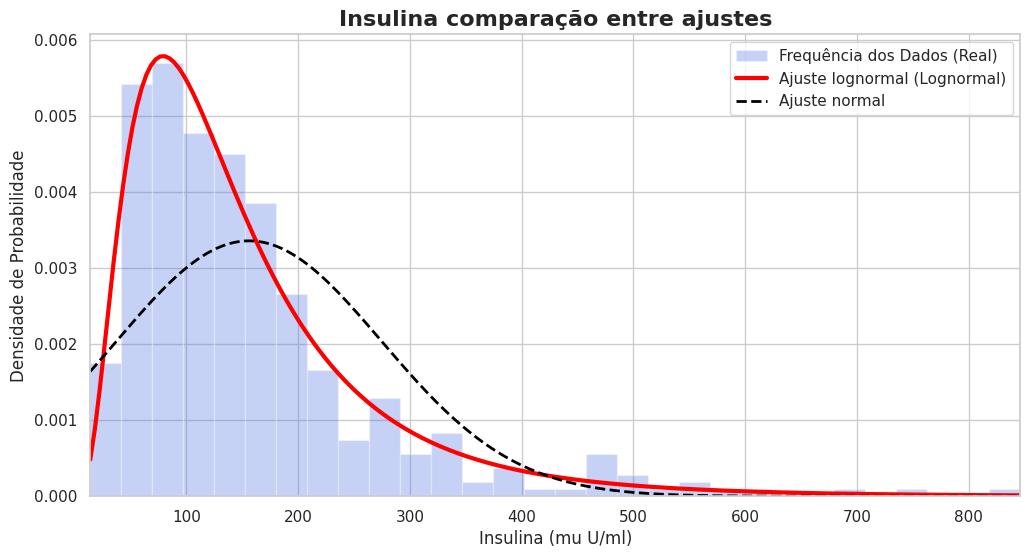

In [ ]:
# @title
# ---------------------------------------------------------
# 4. VERIFICAÇÃO VISUAL DA MAIS ASSIMÉTRICA (Insulina)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

dados_insulina = df_limpo['Insulin'].dropna()

# Descobre automaticamente a melhor distribuição na tabela
melhor_dist_insulina = tabela_campeoes[tabela_campeoes['variavel'] == 'Insulin'].iloc[0]['melhor_distribuicao']

# 1. Histograma base
dados_insulina.plot.hist(density=True, bins=30, color='royalblue', alpha=0.3, label='Frequência dos Dados (Real)')

x = np.linspace(dados_insulina.min(), dados_insulina.max(), 200)

# 2. Plota a curva teórica VENCEDORA (Vermelha)
dist_vencedora = distribuicoes[melhor_dist_insulina]
params_venc = dist_vencedora.fit(dados_insulina if dados_insulina.min() > 0 else dados_insulina + 0.0001)
plt.plot(x, dist_vencedora.pdf(x, *params_venc), color='red', lw=3, label=f'Ajuste lognormal ({melhor_dist_insulina.capitalize()})')

# 3. Plota a curva NORMAL para contraste (Preta Tracejada)
params_norm = stats.norm.fit(dados_insulina)
plt.plot(x, stats.norm.pdf(x, *params_norm), color='black', lw=2, linestyle='--', label='Ajuste normal')

plt.title('Insulina comparação entre ajustes', fontsize=16, fontweight='bold')
plt.xlabel('Insulina (mu U/ml)', fontsize=12)
plt.ylabel('Densidade de Probabilidade', fontsize=12)
plt.legend()
plt.xlim(dados_insulina.min(), dados_insulina.max())
plt.show()

## <font color="blue">5. Análises Gráficas e Relações Fisiológicas

Para consolidar o entendimento da base de dados antes da etapa de modelagem preditiva, este tópico é dedicado à **análise gráfica multivariada**. O objetivo é ir além da estatística descritiva isolada e avaliar visualmente como as variáveis se comportam em conjunto e, principalmente, como elas respondem à presença da patologia (Diabetes Tipo 2).





Outcome,0,1
Pregnancies,2.721374,4.469231
Glucose,111.431298,145.192308
BloodPressure,68.969466,74.076923
SkinThickness,27.251908,32.961538
Insulin,130.854962,206.846154
BMI,31.750763,35.777692
DiabetesPedigreeFunction,0.472168,0.625585
Age,28.347328,35.938462


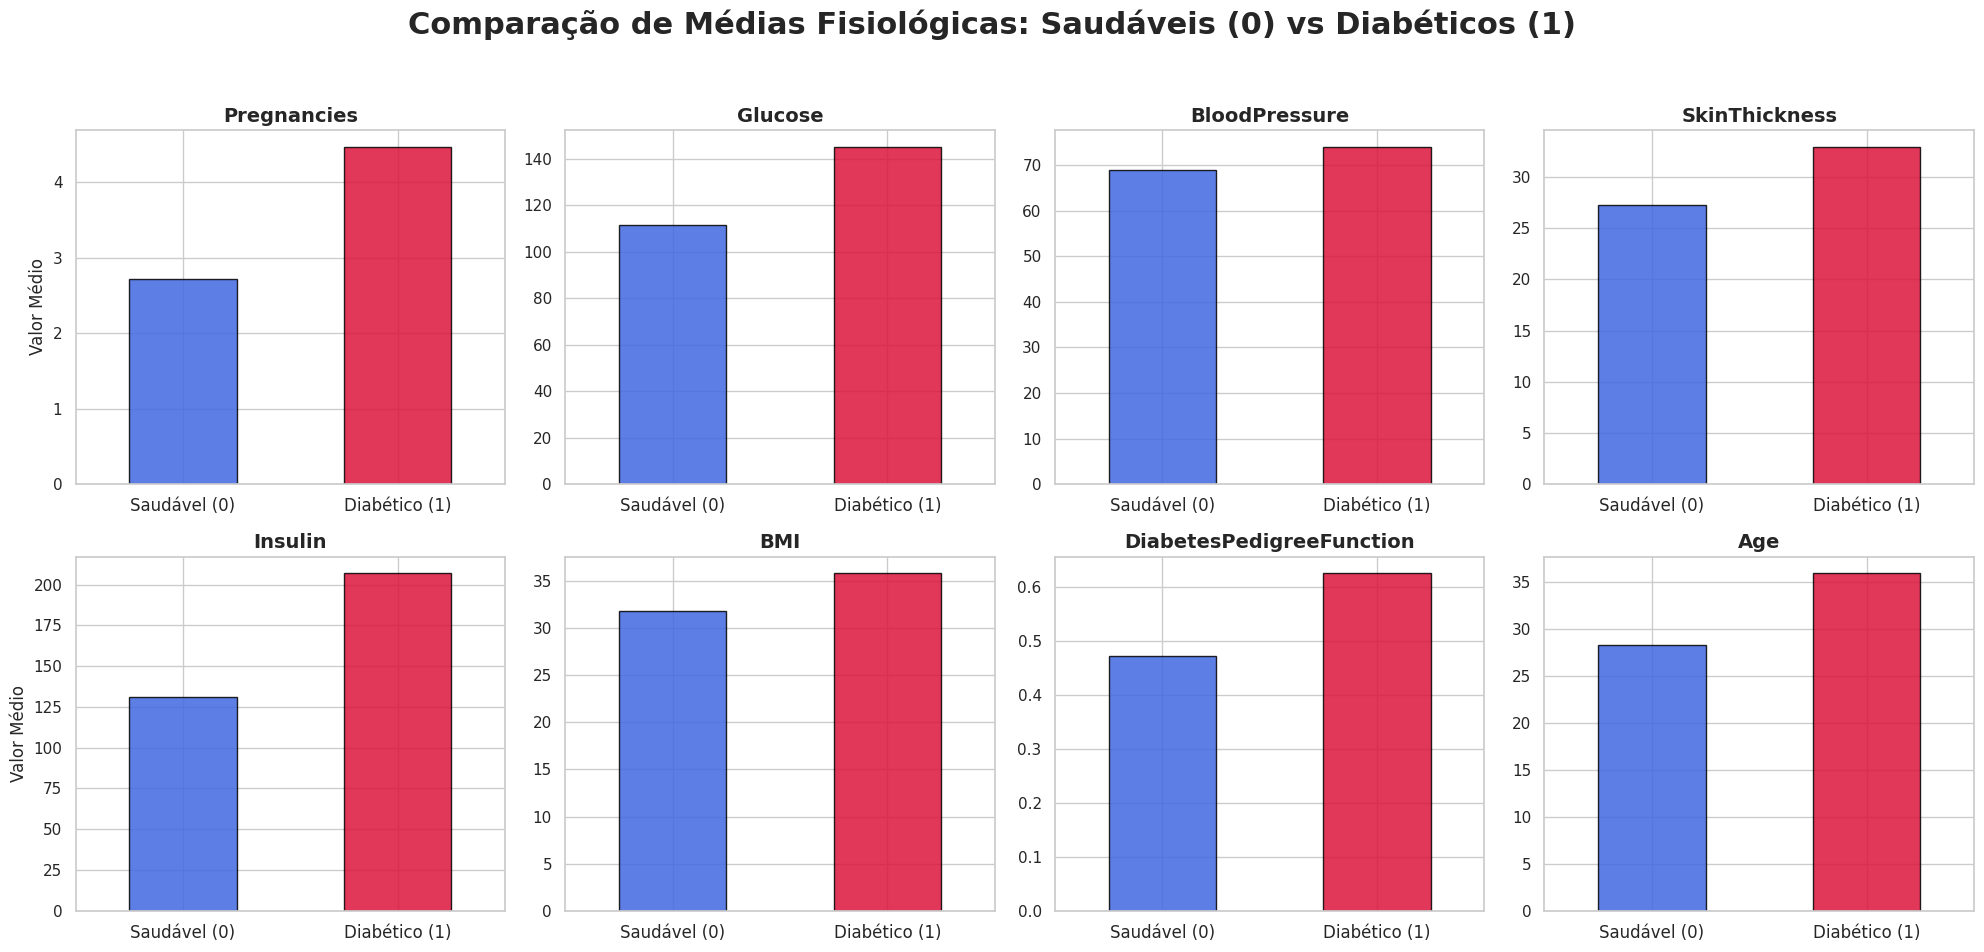

In [ ]:
# @title <font color="blue"> 5.1 Comparação do Perfil Fisiológico
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cálculo das médias
medias_por_diagnostico = df_limpo.groupby('Outcome').mean()

display(medias_por_diagnostico.T)

# 2. Verificação Visual: Painel de Múltiplos Eixos (Subplots)
sns.set_theme(style="whitegrid")

# Criando uma grade 2x4 para abrigar as 8 variáveis separadamente
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle('Comparação de Médias Fisiológicas: Saudáveis (0) vs Diabéticos (1)', fontsize=22, fontweight='bold')

colunas = medias_por_diagnostico.columns
cores = ['#4169E1', '#DC143C'] # Azul (0) e Vermelho (1)

# Loop para desenhar cada mini-gráfico
for i, col in enumerate(colunas):
    row = i // 4
    col_idx = i % 4
    ax = axes[row, col_idx]

    # Plotando a barra da variável específica
    medias_por_diagnostico[col].plot(kind='bar', ax=ax, color=cores, edgecolor='black', alpha=0.85)

    # Ajustes estéticos de cada mini-gráfico
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.set_xticklabels(['Saudável (0)', 'Diabético (1)'], rotation=0, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Valor Médio' if col_idx == 0 else '') # Bota legenda no Y só na primeira coluna

# Ajuste fino para os gráficos não se atropelarem
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



###<font color="blue"> Análise do Gráfico de Barras

* **Gatilhos de Alta Amplitude (Glicose e Insulina):** Fica evidente no gráfico que a `Glucose` e a `Insulin` são os principais diferenciais entre os dois grupos. O nível médio de glicose salta drasticamente no grupo 1, acompanhado por um esforço (pico) de produção de insulina, o que caracteriza perfeitamente o quadro de Resistência à Insulina no Diabetes Tipo 2.
* **Fatores Físicos (IMC e Idade):** As variáveis `BMI` (Índice de Massa Corporal) e `Age` (Idade) também apresentam valores médios maiores no grupo 1, confirmando a correlação clínica entre sobrepeso, avanço da idade e o desenvolvimento da patologia.
* **Variáveis de Regime Estável:** A `BloodPressure` (Pressão Arterial) praticamente não apresenta diferença entre os grupos. Como já validado pelo teste de aderência (comportamento próximo à Normal), a pressão atua como uma variável de regime permanente nesta base de dados, indicando que ela isoladamente é uma preditora fraca para o diagnóstico do Diabetes.

> **Conclusão Técnica:** O modelo de classificação futuro deverá dar um peso preditivo (*feature importance*) muito maior às variáveis metabólicas (Glicose, Insulina e IMC) do que às hemodinâmicas (Pressão). O cálculo de médias comprova que o estado da doença é acionado por transientes específicos, e não por uma degradação generalizada de todos os sinais vitais.

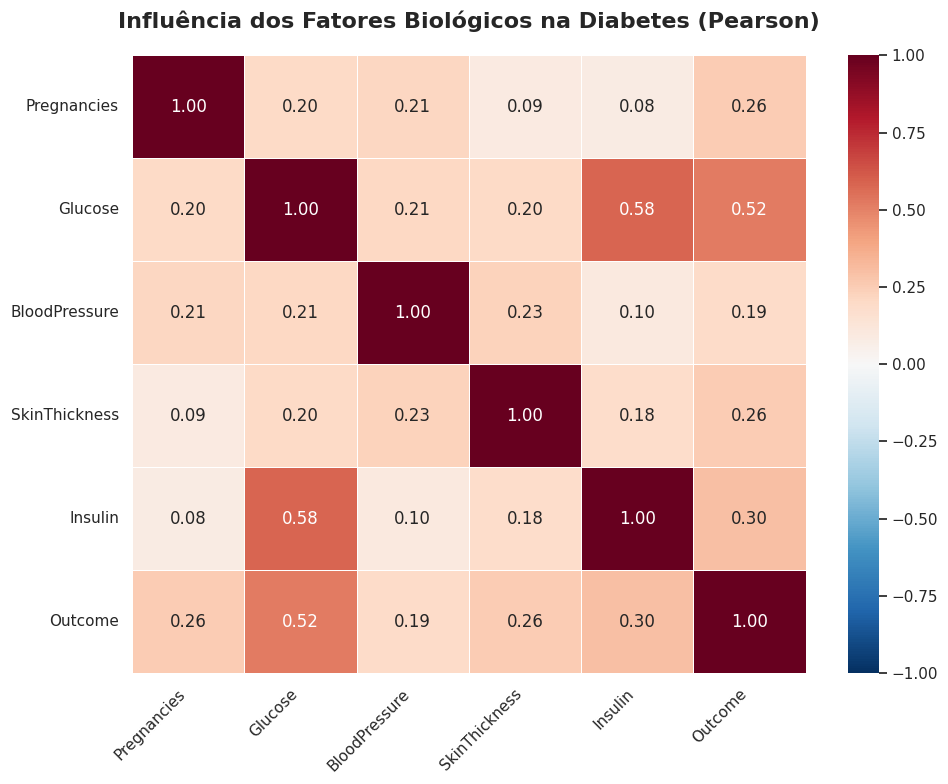

In [ ]:
# @title <font color='purple'>  5.2 Matriz de correlação de pearson
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando os fatores solicitados + Resultado (Outcome)
fatores = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'Outcome']
df_mapa = df_limpo[fatores]

# Configurando o tamanho e o estilo da figura
plt.figure(figsize=(10, 8))
sns.set_theme(style="white") # Fundo branco para destacar as cores do grafico

# Gerando a Matriz de Pearson
# Parâmetros adicionados: vmin e vmax travam a escala de cores de -1 a 1.
sns.heatmap(df_mapa.corr(), annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)

plt.title('Influência dos Fatores Biológicos na Diabetes (Pearson)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

**Interpretação da Matriz de Correlação e Cuidados Metodológicos:**

1. **A Glicose:** Como previsto pela análise gráfica anterior, a `Glucose` apresenta a maior correlação positiva com o `Outcome` (diagnóstico). Isso confirma matematicamente que o descontrole glicêmico é o eixo central e o "sinal preditor" mais forte da patologia.
2. **Pressão Arterial (Fator Neutro):** A correlação entre `BloodPressure` e `Outcome` é muito próxima de zero. Isso atesta que a pressão arterial, operando em regime quase constante, não possui associação linear direta com a ocorrência do diabetes nesta base específica.
3. **Colinearidade Biológica:** É possível notar correlações secundárias entre variáveis preditoras, como entre `SkinThickness` (dobra cutânea) e `Insulin`. Pacientes com maior tecido adiposo subcutâneo tendem a apresentar maior resistência à insulina, exigindo maior produção do hormônio.

> **Cuidado Metodológico (Correlação x Causalidade):**
Conforme as boas práticas de análise de dados reais, é vital ressaltar que correlação não implica causalidade isolada. A alta correlação da Glicose não significa que ela *causa* o diabetes por si só, mas sim que ela é o sintoma central da falha do sistema endócrino. O modelo de aprendizado de máquina não aprenderá as causas, mas sim reconhecerá esse padrão de falha.

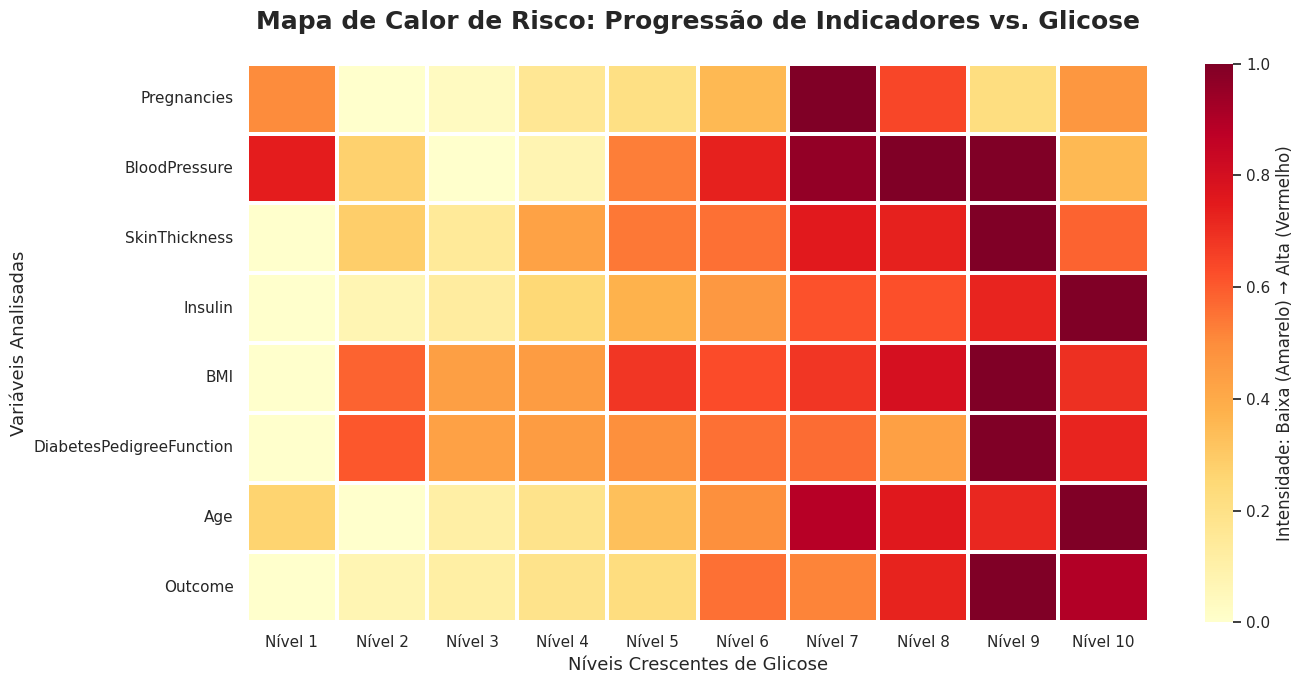

In [ ]:
# @title <font color='red'>  5.3 Mapa de Calor
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Preparação e Agrupamento
df_evolucao = df_limpo.copy()
df_evolucao['Glucose_Bins'] = pd.cut(df_evolucao['Glucose'], bins=10)
df_tendencia = df_evolucao.groupby('Glucose_Bins', observed=True).mean().drop(columns=['Glucose'])

# 2. Normalização
scaler = MinMaxScaler()
df_tendencia_norm = pd.DataFrame(
    scaler.fit_transform(df_tendencia),
    columns=df_tendencia.columns,
    index=[f"Nível {i+1}" for i in range(10)]
).T

# 3. Configuração da Figura
plt.figure(figsize=(14, 7))
sns.set_theme(style="white")

# 4. Geração do Mapa de Calor (Escala de Alerta)
heatmap_alert = sns.heatmap(
    df_tendencia_norm,
    annot=False,
    cmap='YlOrRd',         # Paleta de cores "quentes" (vermelho, no caso)
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': 'Intensidade: Baixa (Amarelo) → Alta (Vermelho)'}
)

# 5. Ajustes de Texto
plt.title('Mapa de Calor de Risco: Progressão de Indicadores vs. Glicose',
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Níveis Crescentes de Glicose', fontsize=13)
plt.ylabel('Variáveis Analisadas', fontsize=13)

# 6. Finalização
plt.tight_layout()
plt.show()

A montagem deste mapa de calor foi baseada no agrupamento dos dados em função da variável Glucose em dez níveis distintos, visto que esta foi identificada como o ponto central da análise. Devido à grande variação de escalas entre as variáveis do banco de dados, como o IMC, que apresenta valores elevados, e o Pedigree, composto por decimais "pequenos", aplicou-se a normalização dos valores. Este procedimento foi fundamental para estabelecer uma base comum de 0 a 1, garantindo que a intensidade das cores reflita a evolução de cada indicador em relação ao seu próprio limite, sem que variáveis de maior magnitude numérica omitissem as demais no gráfico.

A leitura deve ser realizada horizontalmente, acompanhando o aumento progressivo dos níveis de glicose. A escolha da paleta de cores Amarelo, Laranja e Vermelho apresentam intuitividade: os tons claros indicam normalidade, enquanto os tons avermelhados sinalizam onde as condições se tornam críticas. Observa-se que a linha do Outcome sofre a mudança mais acentuada de tonalidade, o que valida visualmente como a elevação da glicose atua como o principal gatilho para a classificação positiva de diabetes no modelo estudado.

Por fim, foi prezada uma visualização limpa, sem anotações numéricas, para priorizar a identificação de tendências visuais. Dessa forma, percebe-se que indicadores como Insulin e BMI não apenas acompanham a tendência da glicose, mas apresentam um escurecimento quase simultâneo conforme o risco aumenta. Este formato de assinatura visual facilita a explicação do comportamento dos dados e reforça a coerência entre os resultados da estatística descritiva, a matriz de correlação de Pearson.

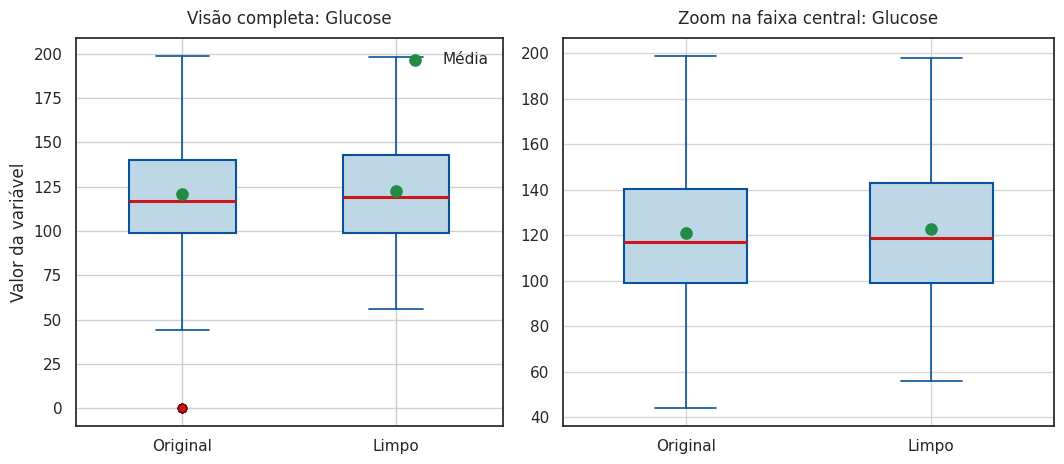

--- Estatísticas de Glucose ---
Original: {'media': 120.89453125, 'mediana': 117.0, 'q1': np.float64(99.0), 'q3': np.float64(140.25), 'desvio_padrao': 31.97261819513622, 'amplitude': 199, 'iiq': np.float64(41.25)}
Limpo: {'media': 122.62755102040816, 'mediana': 119.0, 'q1': np.float64(99.0), 'q3': np.float64(143.0), 'desvio_padrao': 30.86078063172473, 'amplitude': 142.0, 'iiq': np.float64(44.0)}




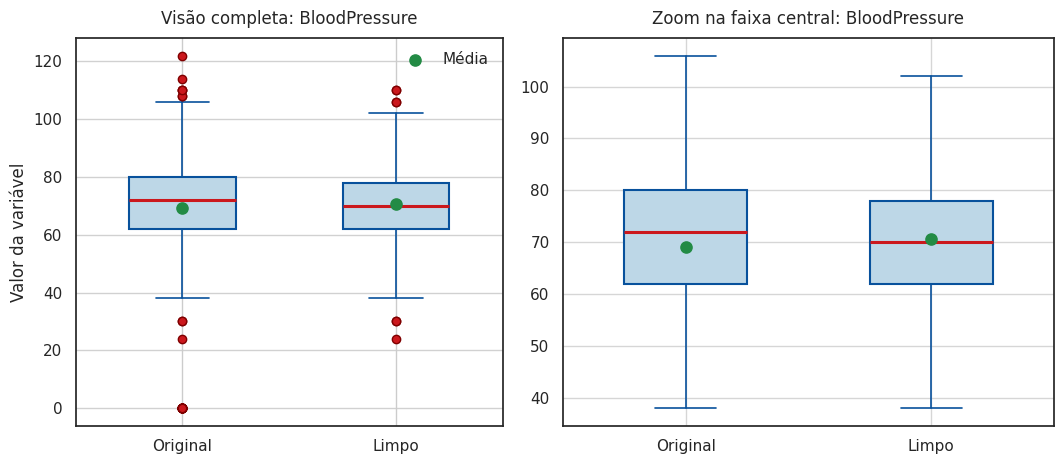

--- Estatísticas de BloodPressure ---
Original: {'media': 69.10546875, 'mediana': 72.0, 'q1': np.float64(62.0), 'q3': np.float64(80.0), 'desvio_padrao': 19.355807170644777, 'amplitude': 122, 'iiq': np.float64(18.0)}
Limpo: {'media': 70.66326530612245, 'mediana': 70.0, 'q1': np.float64(62.0), 'q3': np.float64(78.0), 'desvio_padrao': 12.496091564966259, 'amplitude': 86.0, 'iiq': np.float64(16.0)}




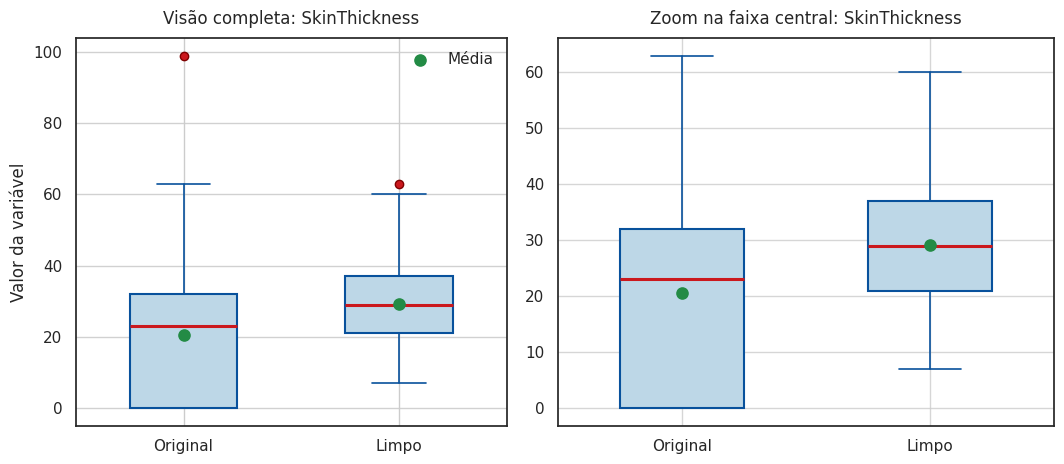

--- Estatísticas de SkinThickness ---
Original: {'media': 20.536458333333332, 'mediana': 23.0, 'q1': np.float64(0.0), 'q3': np.float64(32.0), 'desvio_padrao': 15.952217567727637, 'amplitude': 99, 'iiq': np.float64(32.0)}
Limpo: {'media': 29.145408163265305, 'mediana': 29.0, 'q1': np.float64(21.0), 'q3': np.float64(37.0), 'desvio_padrao': 10.516423853999346, 'amplitude': 56.0, 'iiq': np.float64(16.0)}




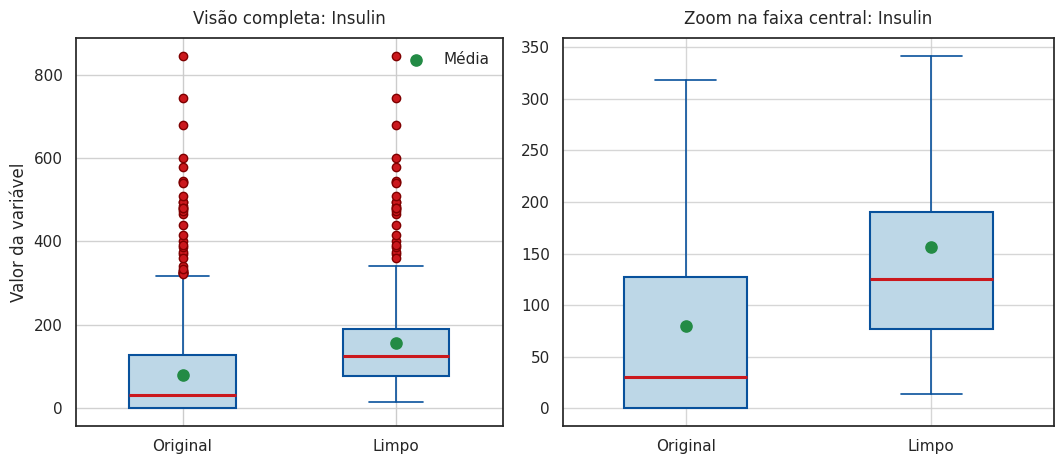

--- Estatísticas de Insulin ---
Original: {'media': 79.79947916666667, 'mediana': 30.5, 'q1': np.float64(0.0), 'q3': np.float64(127.25), 'desvio_padrao': 115.24400235133817, 'amplitude': 846, 'iiq': np.float64(127.25)}
Limpo: {'media': 156.05612244897958, 'mediana': 125.5, 'q1': np.float64(76.75), 'q3': np.float64(190.0), 'desvio_padrao': 118.84168976351212, 'amplitude': 832.0, 'iiq': np.float64(113.25)}




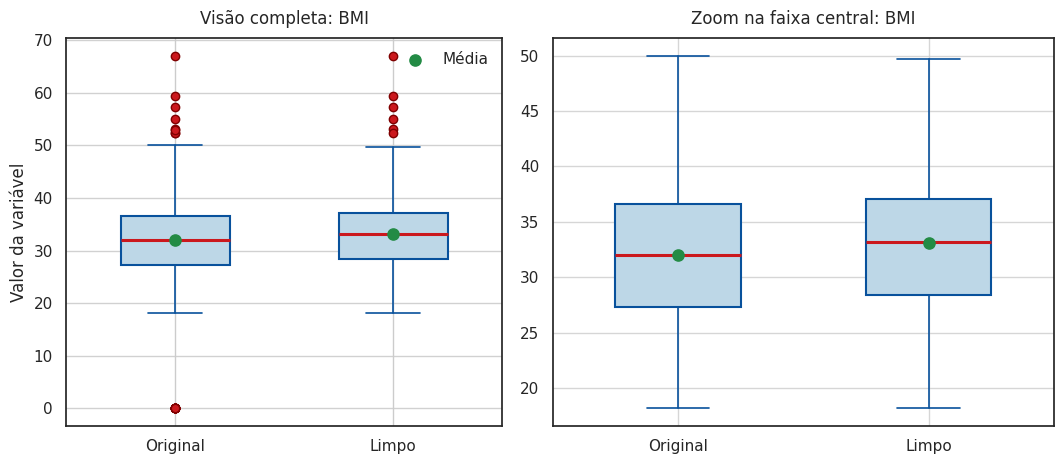

--- Estatísticas de BMI ---
Original: {'media': 31.992578125, 'mediana': 32.0, 'q1': np.float64(27.3), 'q3': np.float64(36.6), 'desvio_padrao': 7.884160320375446, 'amplitude': 67.1, 'iiq': np.float64(9.3)}
Limpo: {'media': 33.08622448979592, 'mediana': 33.2, 'q1': np.float64(28.4), 'q3': np.float64(37.1), 'desvio_padrao': 7.027659204401524, 'amplitude': 48.89999999999999, 'iiq': np.float64(8.700000000000003)}




In [ ]:
#@title <font color = 'green'> 5.4 O efeito de um valor extremo analizados no grafico de boxplot
#Lucas Pereira
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as st

# Lista de colunas que você quer analisar
colunas_de_interesse = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Definindo o estilo fora para não repetir código
estilo = dict(
    tick_labels=['Original', 'Limpo'],
    patch_artist=True, widths=0.5,# permite que você pinte o interior da caixa (usando o facecolor abaixo).
    boxprops=dict(facecolor='#bdd7e7', edgecolor='#08519c', linewidth=1.5),#A Caixa - Representa os 50% centrais dos dados)
    medianprops=dict(color='#cb181d', linewidth=2.2),#linha vermelha
    whiskerprops=dict(color='#08519c', linewidth=1.2),#As Hastes - Dispersão dos dados "normais")
    capprops=dict(color='#08519c', linewidth=1.2),#As barrinhas nas pontas das hastes
    flierprops=dict(marker='o', markerfacecolor='#cb181d', markeredgecolor='#7f0000', markersize=6),#pontos vermelhos
)

# --- A função do professor

def resumo_numerico(dados):
    dados_ordenados = sorted(dados)#poe em ordem crescente ou decrescente
    q1, q2, q3 = np.percentile(dados_ordenados, [25, 50, 75])#medida estatística que indica o valor abaixo do qual uma determinada porcentagem de observações em um conjunto de dados cai.
    #percentile define o q1,q2 e o q3
    return {
        'media': st.mean(dados), #soma dos valores divido pelo total
        'mediana': st.median(dados),#é a metade exata do numero de valores
        'q1': q1,
        'q3': q3,
        'desvio_padrao': st.stdev(dados),#indica o quanto os dados de um conjunto estão próximos ou distantes da média
        'amplitude': max(dados) - min(dados),
        'iiq': q3 - q1,#são os valores dentro da box
    }
# Loop para processar e plotar cada coluna
for col in colunas_de_interesse:
    #vai pegar cada coluna de valor e rodar ela
    # 1. Preparação dos dados
    dados_orig = df[col] #dados sujos
    dados_limpos = df_limpo[col]#dados limpos

    # 2. Cálculo das médias
    medias = [np.mean(dados_orig), np.mean(dados_limpos)] #media de cada dado

    # 3. Plotagem
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.8), gridspec_kw={'width_ratios': [1.0, 1.15]})
    #subplots 1,2 = cria uma linha e duas colunas plots,como se fosse uma matriz
    #width_ratios: Isso define o tamanho lateral dos graficos.Esqueda 1 e direita 1.15
    # Gráfico 1: Visão completa
    #o axes 0 indica a coluna 0 ou a primeira coluna
    axes[0].boxplot([dados_orig, dados_limpos], **estilo)
    axes[0].grid(axis='y', linestyle='-', alpha=0.9)
    axes[0].grid(axis='x', linestyle='-', alpha=1.0)
    axes[0].scatter([1, 2], medias, color='#238b45', s=65, zorder=3, label='Média')# scatter é a linha que pinta o ponto verde no seu gráfico.zorder é a camada
    axes[0].set_title(f'Visão completa: {col}', pad=10)#pad 10 é o espaçamento do texto para a linha do topo do grafico
    axes[0].set_ylabel('Valor da variável')
    axes[0].legend(frameon=False, loc='upper right')

    # Gráfico 2: Zoom na faixa central
    axes[1].boxplot([dados_orig, dados_limpos], showfliers=False, **{k: v for k, v in estilo.items() if k != 'flierprops'})
    #showfliers false não mostra as bolinhas vermelhas. k:...vai copiar tudo, exceto a configuração chamada flierprops
    axes[1].scatter([1, 2], medias, color='#238b45', s=65, zorder=3)
    axes[1].set_title(f'Zoom na faixa central: {col}', pad=10)
    # axes[1].grid(alpha=0.35)
    axes[1].grid(axis='x', linestyle='-', alpha=0.8)
    axes[1].grid(axis='y', linestyle='-', alpha=0.8)

    plt.tight_layout()#reorganiza os dados dos grafico para que fique tudo alinhado,sem sobreposição.
    plt.show()

    # Imprimir resumo numérico para cada coluna
    print(f'--- Estatísticas de {col} ---')
    print('Original:', resumo_numerico(dados_orig))
    print('Limpo:', resumo_numerico(dados_limpos))
    print('\n')



#Interpretação dos graficos Boxplot
## Análise de Tendência Central e Assimetria:
* A interpretação estatística dos gráficos fundamenta-se na comparação entre a mediana (linha vermelha), que representa o valor central robusto da amostra, e a média aritmética (ponto verde), que atua como o centro de gravidade dos dados. Observa-se que, no conjunto original, o deslocamento acentuado da média em relação à mediana deixa claro uma assimetria causada pela presença de registros nulos (zeros), que distorciam a distribuição estatística.
* A convergência observada entre a média e a mediana no conjunto tratado (após a limpeza) demonstra uma estabilização da distribuição, sugerindo que as variáveis fisiológicas agora seguem um comportamento estatístico mais próximo da normalidade. Essa redução na assimetria é um indicador importante de qualidade, pois minimiza a influência de valores atípicos (outliers), com dados que representam fielmente a fisiologia dos pacientes.

## Os "pontinhos" vermelhos no grafico
* Os pontos vermelhos identificados nos gráficos representam outliers estatísticos, valores que divergem significativamente do intervalo interquartil da amostra. Em variáveis fisiológicas, como a Insulina e a Glicose, a presença desses pontos em valores extremos (muito acima ou abaixo da faixa fisiológica esperada) pode indicar ruídos de coleta ou erros sistemáticos no registro dos dados. A visualização destes pontos é crucial para justificar a etapa de pré-processamento dos dados, uma vez que a manutenção de tais outliers no conjunto de treinamento poderia induzir o modelo de aprendizagem a aprender correlações espúrias por exemplo, reduzindo sua capacidade de generalização e, consequentemente, sua precisão.
##O problema do Q1 = 0
* Quando analisados os graficos, nota-se que  alguns O valor de Q1 é 0,oq ue pode causar duvida, geralmente na "coluna" original.Por exemplo, a variável SkinThickness possuía uma alta incidência de registros nulos (zeros), ocupando mais de 25% da amostra total. Isso demonstra claramente que os dados brutos não refletiam o comportamento fisiológico da população. A transição para Q1=21.0 no "coluna" tratado confirma que a limpeza eliminou a distorção introduzida por esses registros inválidos, permitindo uma análise estatística baseada em medidas reais.
##Conclusão
* Em linhas gerais, a análise comparativa via boxplots confirmou a necessidade do tratamento de dados. Notou-se que o conjunto original apresentava inconsistências críticas, sendo a presença de valores nulos (zeros) em variáveis onde estes não são fisiologicamente possíveis. Dado isso, tais valores atuam como *outliers* (dados que se distanciam radicalmente de todos os outros em um conjunto) que distorcem as medidas de tendência central, como a média e a mediana. A remoção destes dados no conjunto 'Limpo' não apenas estabilizou os indicadores estatísticos, mas garantiu que o modelo de Machine Learning seja treinado com dados que refletem o comportamento real do sistema, evitando que ruídos de coleta prejudiquem a capacidade preditiva do classificador.

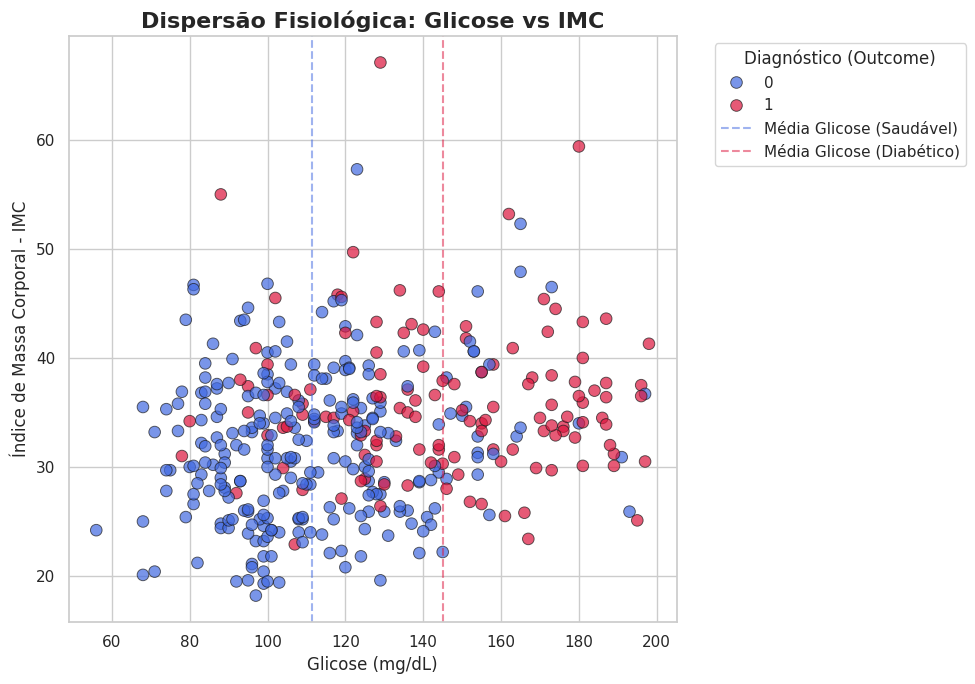

In [ ]:
# @title <font color="purple"> 5.5 Scatter Plot: Glicose vs IMC

import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Criando o Gráfico de Dispersão (Scatter Plot)
# Usamos alpha=0.7 para que pontos sobrepostos fiquem mais escuros (densidade)
sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    palette=['#4169E1', '#DC143C'], # Azul para 0, Vermelho para 1
    data=df_limpo,
    s=70,          # Tamanho dos pontos
    alpha=0.7,     # Transparência
    edgecolor='k'  # Borda preta nos pontos para contraste
)

# Adicionando linhas de referência (Médias de cada grupo para Glicose)
media_glicose_saudavel = df_limpo[df_limpo['Outcome'] == 0]['Glucose'].mean()
media_glicose_diabetico = df_limpo[df_limpo['Outcome'] == 1]['Glucose'].mean()

plt.axvline(media_glicose_saudavel, color='#4169E1', linestyle='--', alpha=0.5, label='Média Glicose (Saudável)')
plt.axvline(media_glicose_diabetico, color='#DC143C', linestyle='--', alpha=0.5, label='Média Glicose (Diabético)')

plt.title('Dispersão Fisiológica: Glicose vs IMC', fontsize=16, fontweight='bold')
plt.xlabel('Glicose (mg/dL)', fontsize=12)
plt.ylabel('Índice de Massa Corporal - IMC', fontsize=12)

# Ajustando a legenda
plt.legend(title='Diagnóstico (Outcome)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Interpretação da Dispersão Espacial:**

* **A Zona Segura:** Observa-se uma concentração densa de pontos azuis (Saudáveis) no quadrante inferior esquerdo. Isso comprova que a manutenção simultânea de baixo IMC e baixa Glicose é uma forte garantidora de ausência da doença.
* **A Zona Crítica:** À medida que avançamos para o quadrante superior direito (alto IMC e alta Glicose), a dominância de pontos vermelhos (Diabéticos) torna-se absoluta. O acúmulo das duas condições praticamente crava o diagnóstico positivo.
* **A "Zona de Confusão" (Overlap):** O ponto focal para a modelagem preditiva está no centro do gráfico (Glicose entre 100 e 140, IMC entre 30 e 40). Nesta área, pontos azuis e vermelhos se misturam intensamente.

> **Conclusão para a Modelagem:** A forte mistura de dados no centro do gráfico (*overlap*) prova que o problema **não é linearmente separável**. Ou seja, um algoritmo simples que tenta passar uma "linha reta" no gráfico falhará miseravelmente em diagnosticar os pacientes intermediários. Essa visualização justifica a futura necessidade de modelos capazes de traçar fronteiras complexas e não-lineares, como *Random Forests*, *Support Vector Machines (SVM) com kernel RBF*, ou Redes Neurais.

##  <font color="purple"> 6. Correlação, causalidade e correlações espúrias</font>

A análise da matriz de Pearson (Tópico 5.2) revelou interações matemáticas importantes entre as variáveis fisiológicas. Algumas dessas correlações são biologicamente plausíveis e esperadas:
* **Glicose e Diagnóstico (Outcome):** Apresentam a maior correlação positiva da base. O descontrole glicêmico é o marcador clínico primário da resistência à insulina.
* **Insulina e Dobra Cutânea (SkinThickness):** Apresentam forte correlação entre si. Fisiologicamente, o acúmulo de tecido adiposo (medido pela dobra cutânea) eleva a resistência celular à insulina, forçando o pâncreas a produzir o hormônio em maiores quantidades (picos observados na análise de curtose).

**O Cuidado Metodológico (Correlação vs. Causalidade)**
Apesar dos fortes indícios matemáticos, o rigor da engenharia de dados exige que não confundamos correlação com causalidade direta e isolada:
1. A alta correlação da Glicose com o `Outcome` não significa que o "açúcar no sangue" é a causa única da doença, mas sim o *sintoma observável* (marcador temporal) da falha sistêmica do metabolismo.
2. A **Idade (Age)** possui correlação moderada com o diagnóstico. No entanto, a passagem do tempo não "causa" diabetes de forma isolada; a idade atua como uma variável de confusão que reflete o tempo de exposição prolongada a hábitos metabólicos nocivos.
3. A ausência de correlação da **Pressão Arterial (BloodPressure)** com o diabetes nesta amostra não significa que hipertensos não tenham diabetes, mas sim que, de forma linear e isolada, a pressão não é o gatilho discriminador para esta patologia específica.

Essa distinção é fundamental para evitar conclusões precipitadas e justificar que o modelo de Inteligência Artificial atuará como um **reconhecedor de padrões de falha**, e não como um simulador mecânico de biologia.

##<font color="purple"> 7. Fechamento conceitual ligado a aprendizado de máquina (T2)</font>

A análise exploratória profunda realizada neste relatório permite definir a estratégia exata para a próxima etapa do projeto (T2). A base de dados Pima Indians Diabetes é perfeitamente adequada para a formulação de problemas preditivos.

**Formulação Escolhida para o T2:**
O problema será modelado como uma **Classificação Binária Supervisionada**. O objetivo será prever a variável alvo `Outcome` (0 = Saudável, 1 = Diabético) a partir da matriz de características (Features) fisiológicas das pacientes.

**Desafios Técnicos Esperados (Mapeados na Análise Exploratória):**
Com base nos testes estatísticos e gráficos elaborados no T1, o modelo enfrentará os seguintes desafios:
1. **Fronteiras Não-Lineares:** O Gráfico de Dispersão (Glicose vs IMC) provou a existência de uma grande "zona de confusão" (sobreposição de classes). Modelos puramente lineares (como Regressão Logística Simples) tendem a falhar. Será necessário testar classificadores capazes de desenhar fronteiras complexas (*Random Forest*, *XGBoost* ou *SVM com kernel RBF*).
2. **Escalas Discrepantes:** A Insulina chega a ultrapassar 200 $\mu U/ml$, enquanto a função de pedigree genético é menor que 1. Isso exigirá uma etapa rigorosa de padronização/normalização dos dados (*StandardScaler* ou *MinMaxScaler*) antes de alimentar algoritmos baseados em distância (como KNN ou SVM).
3. **Robustez a Outliers:** O teste de aderência e a análise de Curtose provaram que variáveis como Insulina operam em distribuições de cauda longa (Lognormal/Gamma), com forte presença de *outliers* naturais (transientes patológicos). Algoritmos sensíveis a extremos precisarão de dados transformados (ex: transformação logarítmica) para não enviesar o treinamento.

## <font color="purple"> 8. Conclusão

Este relatório consolidou a primeira etapa do fluxo de Engenharia e Ciência de Dados, transformando uma base de dados bruta em um repositório estruturado, limpo e estatisticamente compreendido, voltado para a área da saúde.

**Síntese dos principais resultados:**
* **Limpeza Crítica:** Variáveis com "zeros impossíveis" (como Glicose e Insulina nulas) foram tratadas com rigor, evitando que dados ausentes disfarçados de zeros corrompessem as médias estatísticas.
* **Comportamento não-Gaussiano:** Através do cálculo do Critério de Informação de Akaike (AIC) e testes de normalidade, provou-se que o sistema biológico patológico não segue distribuições normais, mas sim distribuições assimétricas de cauda longa (Lognormal e Gamma), impulsionadas por picos transientes.
* **Preditores Dominantes:** As análises gráficas multivariáveis e de correlação isolaram a Glicose, o IMC e a Insulina como as grandezas de maior peso discriminatório para a detecção da doença, enquanto variáveis hemodinâmicas (Pressão) atuam em regime de estabilidade secundária.

Por fim, o conjunto de dados encontra-se validado, consistente e metodologicamente preparado para alimentar os pipelines de *Machine Learning* propostos para o Trabalho 2 (T2), com todos os ruídos, assimetrias e escalas devidamente mapeados para garantir um treinamento de alta precisão.